# 24RB1003 松澤颯斗

# 演習2（実装）：Cliff Walking で SARSA vs Q学習

### 課題

4×12 の Cliff Walking 環境を作成し，SARSA と Q学習を比較する．

- 左下の $S$ をスタート，右下の $G$ をゴールとする．
- 下辺の $S$ と $G$ の間を崖とする．
- 行動は上下左右の4種類で，枠外へ移動しようとした場合は同じ場所に留まる．
- 1歩ごとの報酬は $-1$，崖に入った場合は報酬 $-100$ を受けて $S$ に戻る．
- $G$ に到達するとエピソードを終了する．
- パラメータは $\varepsilon=0.1,\ \alpha=0.5,\ \gamma=1$ とする．

行うことは以下である．

1. SARSA と Q学習で $Q(s,a)$ を学習する（$\varepsilon$-greedy で行動する）．
2. 学習後の貪欲方策の経路を可視化し，両者の違いを比較する．
3. エピソードごとの合計報酬の推移を両手法で比較する．

In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### 準備：Cliff Walking 環境を定義する

In [2]:
# グリッドの大きさを設定する
n_rows = 4
n_cols = 12

# スタート，ゴール，崖の位置を設定する
start = (3, 0)
goal = (3, 11)
cliff = {(3, col) for col in range(1, 11)}

# 行動を設定する
# 0: 上，1: 下，2: 左，3: 右
actions = {
    0: (-1, 0),
    1: (1, 0),
    2: (0, -1),
    3: (0, 1),
}
action_symbols = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→",
}

# 学習パラメータを設定する
epsilon = 0.1
alpha = 0.5
gamma = 1.0
n_episodes = 500

# 状態をQテーブルの行番号に変換する
def state_to_index(state):
    row, col = state
    return row * n_cols + col


print("grid shape:", (n_rows, n_cols))
print("start:", start)
print("goal:", goal)
print("cliff:", sorted(cliff))
print("epsilon:", epsilon)
print("alpha:", alpha)
print("gamma:", gamma)

grid shape: (4, 12)
start: (3, 0)
goal: (3, 11)
cliff: [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10)]
epsilon: 0.1
alpha: 0.5
gamma: 1.0


In [3]:
def step(state, action):
    """現在の状態と行動から，次状態・報酬・終了判定を返す関数"""
    if state == goal:
        return goal, 0, True

    dr, dc = actions[action]
    next_row = max(0, min(n_rows - 1, state[0] + dr))
    next_col = max(0, min(n_cols - 1, state[1] + dc))
    next_state = (next_row, next_col)

    # 崖に入った場合は報酬 -100 を受け，スタートに戻る
    if next_state in cliff:
        return start, -100, False

    # ゴールに到達した場合は報酬 -1 を受け，エピソードを終了する
    if next_state == goal:
        return goal, -1, True

    # 通常の移動では報酬 -1
    return next_state, -1, False


# 遷移の例を確認する
examples = [
    (start, 0),       # スタートから上へ
    (start, 3),       # スタートから右へ（崖）
    ((2, 11), 1),     # ゴールの1つ上から下へ
    ((0, 0), 0),      # 枠外へ移動
]

for state, action in examples:
    next_state, reward, done = step(state, action)
    print(
        f"state={state}, action={action_symbols[action]} "
        f"-> next_state={next_state}, reward={reward}, done={done}"
    )

state=(3, 0), action=↑ -> next_state=(2, 0), reward=-1, done=False
state=(3, 0), action=→ -> next_state=(3, 0), reward=-100, done=False
state=(2, 11), action=↓ -> next_state=(3, 11), reward=-1, done=True
state=(0, 0), action=↑ -> next_state=(0, 0), reward=-1, done=False


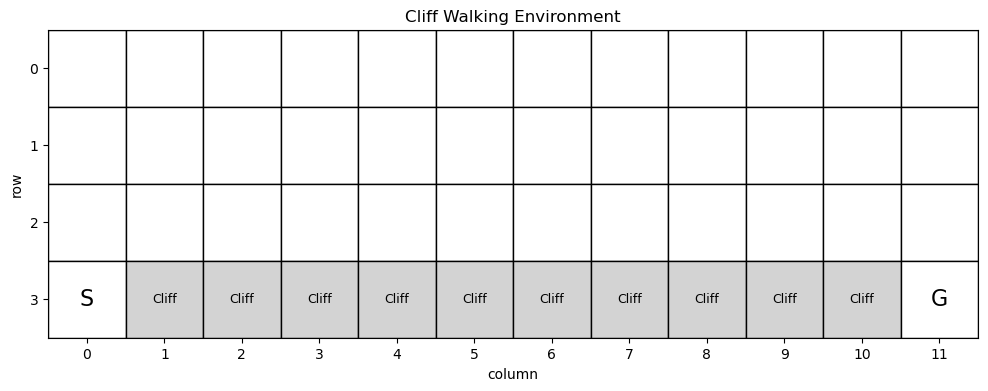

In [4]:
# Cliff Walking 環境を可視化する
fig, ax = plt.subplots(figsize=(12, 4))

for row in range(n_rows):
    for col in range(n_cols):
        state = (row, col)

        if state in cliff:
            ax.add_patch(
                plt.Rectangle(
                    (col - 0.5, row - 0.5), 1, 1,
                    facecolor="lightgray", edgecolor="black"
                )
            )
            ax.text(col, row, "Cliff", ha="center", va="center", fontsize=9)
        else:
            ax.add_patch(
                plt.Rectangle(
                    (col - 0.5, row - 0.5), 1, 1,
                    facecolor="white", edgecolor="black"
                )
            )

ax.text(start[1], start[0], "S", ha="center", va="center", fontsize=16)
ax.text(goal[1], goal[0], "G", ha="center", va="center", fontsize=16)

ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)
ax.set_xticks(range(n_cols))
ax.set_yticks(range(n_rows))
ax.set_title("Cliff Walking Environment")
ax.set_xlabel("column")
ax.set_ylabel("row")
plt.show()

### 1. SARSA と Q学習で $Q(s,a)$ を学習する

行動は $\varepsilon$-greedy 方策で選択する．

SARSA の更新式は

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+\gamma Q(s',a')-Q(s,a)
\right]
$$

である．実際に次状態で選択した行動 $a'$ の価値を使うため，on-policy の手法である．

Q学習の更新式は

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+\gamma\max_{a'}Q(s',a')-Q(s,a)
\right]
$$

である．実際に選択する行動とは関係なく，次状態で最大の行動価値を使うため，off-policy の手法である．

In [5]:
def epsilon_greedy(Q, state, epsilon, rng):
    """epsilon-greedy 方策によって行動を選択する関数"""
    if rng.random() < epsilon:
        # 確率 epsilon でランダムな行動を選ぶ
        return int(rng.integers(len(actions)))

    # 確率 1-epsilon で現在のQ値が最大の行動を選ぶ
    q_values = Q[state_to_index(state)]
    max_q = np.max(q_values)

    # 最大値が複数ある場合は，その中からランダムに選ぶ
    best_actions = np.flatnonzero(np.isclose(q_values, max_q))
    return int(rng.choice(best_actions))

In [6]:
def train_sarsa(seed=1):
    """SARSAによってQテーブルを学習する関数"""
    rng = np.random.default_rng(seed)
    Q = np.zeros((n_rows * n_cols, len(actions)))

    episode_rewards = []
    cliff_falls = []

    for episode in range(n_episodes):
        state = start
        action = epsilon_greedy(Q, state, epsilon, rng)

        total_reward = 0
        n_falls = 0

        for _ in range(1000):
            next_state, reward, done = step(state, action)
            total_reward += reward

            if reward == -100:
                n_falls += 1

            state_index = state_to_index(state)

            if done:
                # 終端状態では次状態のQ値を加えない
                td_target = reward
                Q[state_index, action] += alpha * (
                    td_target - Q[state_index, action]
                )
                break

            # SARSAでは実際に次状態で選んだ行動を更新に使う
            next_action = epsilon_greedy(Q, next_state, epsilon, rng)
            next_index = state_to_index(next_state)

            td_target = reward + gamma * Q[next_index, next_action]
            Q[state_index, action] += alpha * (
                td_target - Q[state_index, action]
            )

            state = next_state
            action = next_action

        episode_rewards.append(total_reward)
        cliff_falls.append(n_falls)

    return Q, np.array(episode_rewards), np.array(cliff_falls)


def train_q_learning(seed=1):
    """Q学習によってQテーブルを学習する関数"""
    rng = np.random.default_rng(seed)
    Q = np.zeros((n_rows * n_cols, len(actions)))

    episode_rewards = []
    cliff_falls = []

    for episode in range(n_episodes):
        state = start
        total_reward = 0
        n_falls = 0

        for _ in range(1000):
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, done = step(state, action)
            total_reward += reward

            if reward == -100:
                n_falls += 1

            state_index = state_to_index(state)

            if done:
                # 終端状態では次状態のQ値を加えない
                td_target = reward
            else:
                # Q学習では次状態における最大Q値を更新に使う
                next_index = state_to_index(next_state)
                td_target = reward + gamma * np.max(Q[next_index])

            Q[state_index, action] += alpha * (
                td_target - Q[state_index, action]
            )

            if done:
                break

            state = next_state

        episode_rewards.append(total_reward)
        cliff_falls.append(n_falls)

    return Q, np.array(episode_rewards), np.array(cliff_falls)

In [7]:
# 同じ乱数シードを使ってSARSAとQ学習を実行する
seed = 1

Q_sarsa, rewards_sarsa, falls_sarsa = train_sarsa(seed=seed)
Q_q_learning, rewards_q_learning, falls_q_learning = train_q_learning(seed=seed)

print("Q_sarsa shape:", Q_sarsa.shape)
print("Q_q_learning shape:", Q_q_learning.shape)

print("\n最後の100エピソードにおける平均合計報酬")
print("SARSA:", rewards_sarsa[-100:].mean())
print("Q-learning:", rewards_q_learning[-100:].mean())

print("\n最後の100エピソードにおける崖への平均転落回数")
print("SARSA:", falls_sarsa[-100:].mean())
print("Q-learning:", falls_q_learning[-100:].mean())

Q_sarsa shape: (48, 4)
Q_q_learning shape: (48, 4)

最後の100エピソードにおける平均合計報酬
SARSA: -20.68
Q-learning: -48.59

最後の100エピソードにおける崖への平均転落回数
SARSA: 0.0
Q-learning: 0.32


### 2. 学習後の貪欲方策の経路を可視化し，両者の違いを比較する

In [8]:
def greedy_path(Q, max_steps=100):
    """学習済みQテーブルから貪欲方策の経路を求める関数"""
    state = start
    path = [state]

    for _ in range(max_steps):
        if state == goal:
            break

        q_values = Q[state_to_index(state)]
        action = int(np.argmax(q_values))
        next_state, _, done = step(state, action)

        path.append(next_state)

        if done:
            break

        # 同じ状態を繰り返した場合はループと判断して終了する
        if next_state in path[:-1]:
            break

        state = next_state

    return path


path_sarsa = greedy_path(Q_sarsa)
path_q_learning = greedy_path(Q_q_learning)

print("SARSAの貪欲経路:")
print(path_sarsa)
print("移動回数:", len(path_sarsa) - 1)

print("\nQ学習の貪欲経路:")
print(path_q_learning)
print("移動回数:", len(path_q_learning) - 1)

SARSAの貪欲経路:
[(3, 0), (2, 0), (1, 0), (1, 1), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)]
移動回数: 17

Q学習の貪欲経路:
[(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]
移動回数: 13


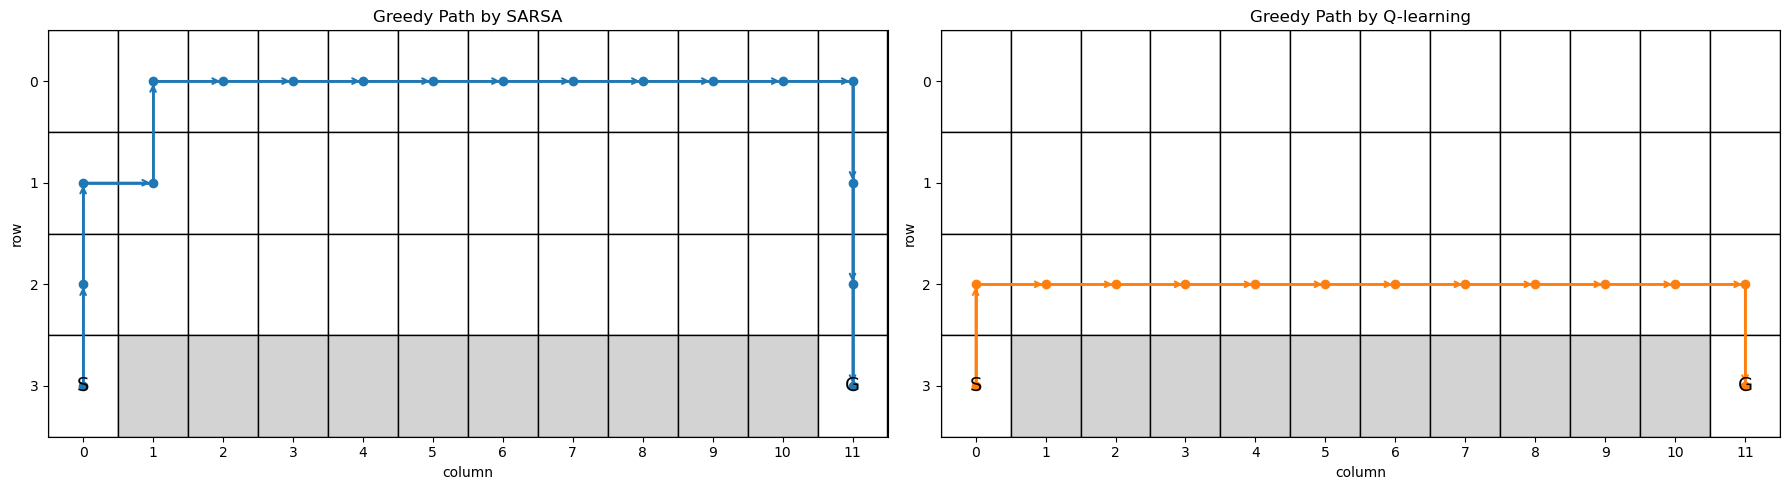

In [9]:
def plot_path(ax, path, title, path_color):
    """Cliff Walking上に経路を描画する関数"""
    for row in range(n_rows):
        for col in range(n_cols):
            state = (row, col)

            if state in cliff:
                facecolor = "lightgray"
            else:
                facecolor = "white"

            ax.add_patch(
                plt.Rectangle(
                    (col - 0.5, row - 0.5), 1, 1,
                    facecolor=facecolor, edgecolor="black"
                )
            )

    # 経路を線と点で描く
    x = [state[1] for state in path]
    y = [state[0] for state in path]
    ax.plot(x, y, marker="o", linewidth=2, color=path_color)

    # 各移動方向を矢印で示す
    for current_state, next_state in zip(path[:-1], path[1:]):
        ax.annotate(
            "",
            xy=(next_state[1], next_state[0]),
            xytext=(current_state[1], current_state[0]),
            arrowprops={"arrowstyle": "->", "color": path_color, "lw": 1.5},
        )

    ax.text(start[1], start[0], "S", ha="center", va="center", fontsize=14)
    ax.text(goal[1], goal[0], "G", ha="center", va="center", fontsize=14)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    ax.set_title(title)


# SARSAとQ学習の貪欲経路を並べて表示する
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

plot_path(ax1, path_sarsa, "Greedy Path by SARSA", "C0")
plot_path(ax2, path_q_learning, "Greedy Path by Q-learning", "C1")

plt.tight_layout()
plt.show()

#### 観察メモ

- SARSA の貪欲経路は崖から距離を取った迂回経路になっている．
- Q学習の貪欲経路は崖の1つ上の行を通る最短経路になっている．
- SARSA の経路は長いが，探索によって行動がずれた場合でも崖に落ちにくい．
- Q学習の経路は短いが，探索中に下方向が選ばれると崖に落ちる危険がある．

### 3. エピソードごとの合計報酬の推移を両手法で比較する

In [10]:
# 乱数によるばらつきを抑えるため，10回の実験結果を平均する
n_runs = 10

sarsa_reward_runs = []
q_learning_reward_runs = []
sarsa_fall_runs = []
q_learning_fall_runs = []

for run_seed in range(n_runs):
    _, rewards_s, falls_s = train_sarsa(seed=run_seed)
    _, rewards_q, falls_q = train_q_learning(seed=run_seed)

    sarsa_reward_runs.append(rewards_s)
    q_learning_reward_runs.append(rewards_q)
    sarsa_fall_runs.append(falls_s)
    q_learning_fall_runs.append(falls_q)

sarsa_reward_runs = np.array(sarsa_reward_runs)
q_learning_reward_runs = np.array(q_learning_reward_runs)
sarsa_fall_runs = np.array(sarsa_fall_runs)
q_learning_fall_runs = np.array(q_learning_fall_runs)

mean_rewards_sarsa = sarsa_reward_runs.mean(axis=0)
mean_rewards_q_learning = q_learning_reward_runs.mean(axis=0)

print("sarsa_reward_runs shape:", sarsa_reward_runs.shape)
print("q_learning_reward_runs shape:", q_learning_reward_runs.shape)

sarsa_reward_runs shape: (10, 500)
q_learning_reward_runs shape: (10, 500)


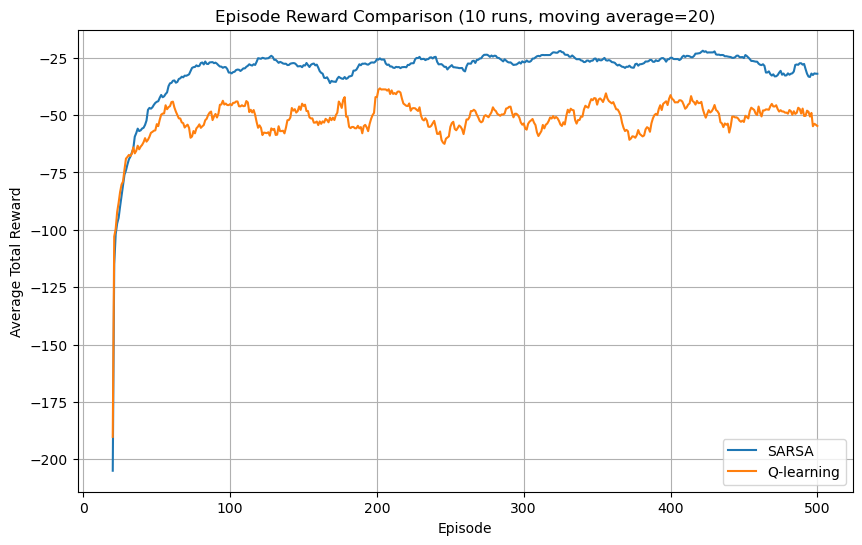

In [11]:
def moving_average(values, window=20):
    """移動平均を計算する関数"""
    weights = np.ones(window) / window
    return np.convolve(values, weights, mode="valid")


window = 20
episodes_for_moving_average = np.arange(window, n_episodes + 1)

sarsa_moving_average = moving_average(mean_rewards_sarsa, window)
q_learning_moving_average = moving_average(mean_rewards_q_learning, window)

# エピソードごとの平均合計報酬を比較する
plt.figure(figsize=(10, 6))

plt.plot(
    episodes_for_moving_average,
    sarsa_moving_average,
    label="SARSA"
)
plt.plot(
    episodes_for_moving_average,
    q_learning_moving_average,
    label="Q-learning"
)

plt.xlabel("Episode")
plt.ylabel("Average Total Reward")
plt.title(f"Episode Reward Comparison ({n_runs} runs, moving average={window})")
plt.legend()
plt.grid()
plt.show()

In [12]:
# 最後の100エピソードの結果を表にまとめる
summary = pd.DataFrame({
    "method": ["SARSA", "Q-learning"],
    "greedy path steps": [
        len(path_sarsa) - 1,
        len(path_q_learning) - 1,
    ],
    "mean reward in last 100 episodes": [
        sarsa_reward_runs[:, -100:].mean(),
        q_learning_reward_runs[:, -100:].mean(),
    ],
    "mean cliff falls in last 100 episodes": [
        sarsa_fall_runs[:, -100:].mean(),
        q_learning_fall_runs[:, -100:].mean(),
    ],
})

summary

,method,greedy path steps,mean reward in last 100 episodes,mean cliff falls in last 100 episodes
0,SARSA,17,-27.780,0.044
1,Q-learning,13,-50.538,0.339


# 考察

SARSA と Q学習の学習後の貪欲経路を比較すると，SARSA は崖から離れた安全な迂回経路を選び，Q学習は崖のすぐ上を通る最短経路を選ぶことが確認できた．

SARSA は on-policy の手法であり，実際に行動している $\varepsilon$-greedy 方策によって選ばれた次行動 $a'$ の価値 $Q(s',a')$ を更新に使う．そのため，探索中に誤って崖へ向かう行動を選び，大きな負の報酬を受ける可能性も $Q$ に反映される．この結果，多少経路が長くても崖から離れた安全な経路を高く評価するようになったと考えられる．

一方，Q学習は off-policy の手法であり，更新時には実際に選択される行動ではなく，$\max_{a'}Q(s',a')$ を用いる．そのため，探索によって崖へ落ちる失敗はターゲット方策の価値には直接反映されず，探索を行わない貪欲方策にとって最短となる崖際の経路を学習したと考えられる．

報酬の推移を見ると，探索を続ける条件では SARSA の方が平均合計報酬が高くなる傾向が確認できた．Q学習の貪欲経路自体は短いが，$\varepsilon$-greedy による探索中には崖へ落ちやすく，$-100$ の報酬を受ける回数が多いためである．したがって，最終的な貪欲経路の短さと，探索を含む学習中の平均報酬は必ずしも一致しないことが分かった．

# AI使用について

ChatGPT を使用して，Cliff Walking 環境の定義，SARSA と Q学習の更新処理，学習後の経路と報酬推移の可視化方法について補助を受けた．AI の出力内容を確認し，授業スライドの条件に合うように修正しながらコードを作成した．